# 📊 Simple Linear Regression Model : Predicting Sunday newspaper circulation based on weekly newspaper circulation

---

### 📝 Problem Statement  
- Design and implement simple linear regression model to predict **Sunday newspaper circulation** based on **daily newspaper circulation**  
- Predict Sunday paper circulation for **200, 300 and 500** daily circulation  
- Evaluate model with **R-square** and **Adjusted R-Square**


In [6]:
import pandas as pd
import numpy as np

In [10]:
df=pd.read_csv('NewsPaperData.csv')
df.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     object 
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), object(1)
memory usage: 948.0+ bytes


In [4]:
df.shape

(34, 3)

In [13]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()


,daily,sunday
daily,1.000000,0.958154
sunday,0.958154,1.000000


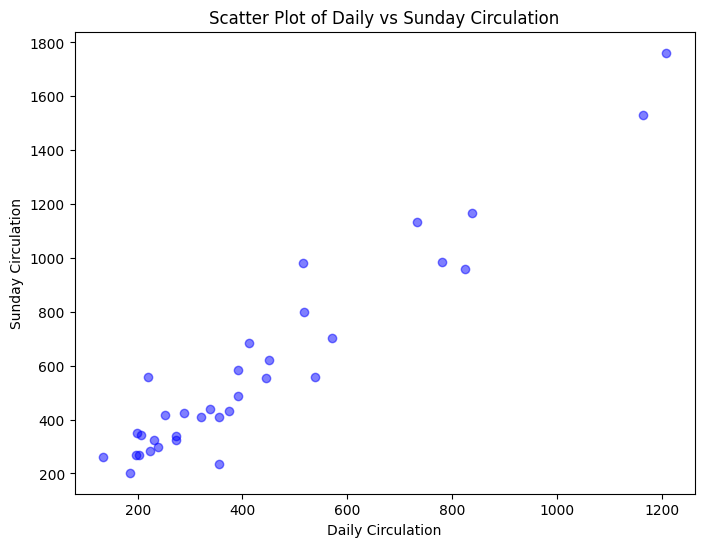

In [14]:
import matplotlib.pyplot as plt

# Extracting daily and Sunday circulation data
daily_data = df['daily']
sunday_data = df['sunday']

# Plotting scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(daily_data, sunday_data, color='blue', alpha=0.5)
plt.title('Scatter Plot of Daily vs Sunday Circulation')
plt.xlabel('Daily Circulation')
plt.ylabel('Sunday Circulation')
#plt.grid(True)
plt.show()


### Fitting a linear regression model

In [16]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.6 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.6 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.6 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.6 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.6 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.6 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.6 MB 1.2 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.6 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.6 MB 1.2 MB/s eta 0:00:06
   ------------- ----------------

In [19]:
import statsmodels.formula.api as smf
model=smf.ols('sunday~daily',data=df).fit()

In [21]:
print(model.params)

Intercept    13.835630
daily         1.339715
dtype: float64


In [22]:
# t and p values
print(f'model t values:\n {model.tvalues}')

model t values:
 Intercept     0.386427
daily        18.934840
dtype: float64


In [24]:
# to predict for 300 daily circulation
13.835630+(1.339715*300)

415.75012999999996

In [25]:
(model.rsquared,model.rsquared_adj)

(np.float64(0.9180596895873295), np.float64(0.9154990548869336))

## Predict for new data points

In [26]:
newdata=pd.Series([200,300,500])

In [27]:
data_pred=pd.DataFrame(newdata,columns=['daily'])

In [28]:
data_pred

,daily
0,200
1,300
2,500


In [29]:
model.predict(data_pred)

0    281.778581
1    415.750057
2    683.693009
dtype: float64

In [30]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           6.02e-19
Time:                        16:16:08   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8356     35.804      0.386      0.702     -59.095      86.766
daily          1.3397      0.071     18.935      0.000       1.196       1.484
==============================================================================
Omnibus:                        3.297   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.192   Jarque-Bera (JB):                1.990
Skew:                           0.396   Prob(JB):                        0.370
Kurtosis:                       3.882   Cond. No.                         965.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""